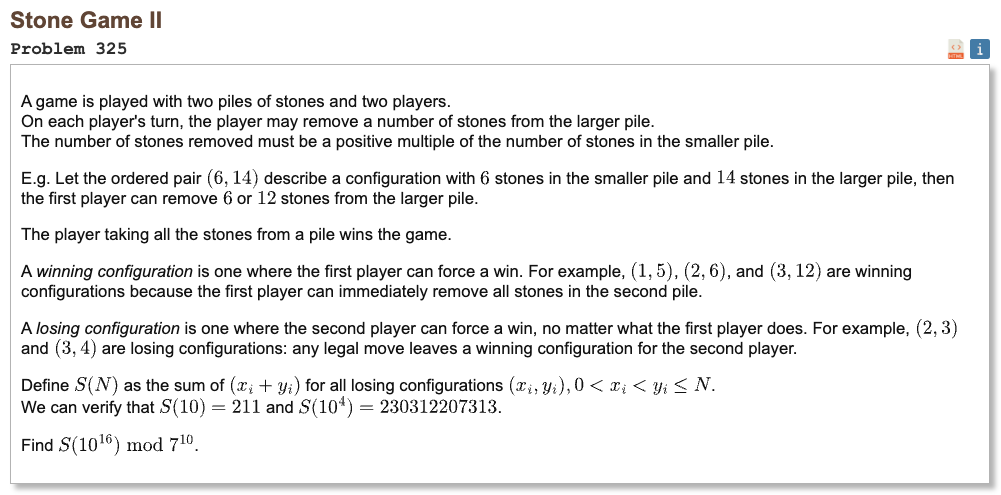

## Initial approach

* losing positions are exactly the pairs where the two piles are close enough
* for a fixed smaller pile, the larger pile only ranges up to a golden-ratio boundary
* split the count into two parts: before the boundary and near the upper limit
* the first part needs fast sums of floor values involving the golden ratio
* use a recursive Beatty-style formula instead of looping to the huge limit
* the second part is just a direct arithmetic sum

In [1]:
import math
from functools import lru_cache

MOD = 7 ** 10

def floor_beta(n):
    return (math.isqrt(5 * n * n) - n) // 2

@lru_cache(None)
def beta_sums(n):
    if n <= 0:
        return 0, 0, 0

    k = floor_beta(n)
    a_k, b_k, c_k = beta_sums(k)

    sum_j = k * (k + 1) // 2
    sum_j2 = k * (k + 1) * (2 * k + 1) // 6

    a = k * n - sum_j - a_k
    b = n * k * k - (2 * sum_j2 - sum_j + 2 * c_k - a_k)
    c = (k * n * (n + 1) - (sum_j2 + 2 * c_k + b_k + sum_j + a_k)) // 2

    return a, b, c

def full_part(n):
    a, b, c = beta_sums(n)
    return 2 * c + (a + b) // 2

def simple_range_sum(a, b):
    if a > b:
        return 0, 0, 0

    count = b - a + 1
    sum_x = (a + b) * count // 2
    sum_x2 = b * (b + 1) * (2 * b + 1) // 6 - (a - 1) * a * (2 * a - 1) // 6

    return count, sum_x, sum_x2

def S(n):
    m = floor_beta(n)
    total = full_part(m)

    a = m + 1
    b = n - 1

    count, sum_x, sum_x2 = simple_range_sum(a, b)

    tail = n * sum_x - sum_x2
    tail += (count * n * (n + 1) - sum_x2 - sum_x) // 2

    return total + tail

assert S(10) == 211
assert S(10 ** 4) == 230312207313

In [2]:
%%time
result = S(10 ** 16) % MOD
print("Result:", result)

Result: 54672965
CPU times: user 127 μs, sys: 16 μs, total: 143 μs
Wall time: 143 μs
